# 3. Agent的基本用法：如何调用Agent

agent.invoke() 是Agent 最基本的同步调用方法，它会阻塞程序执行直到返回最终结果。具体的：

* 输入：传入的参数为字典类型，字典内通过 `messages` 字段传递消息列表，即：`{"messages": [{"role": "...", "content": "..."}]}`
* 输出：通过 invoke 调用 Agent，底层可能会经历多轮交互，返回的是完整的消息列表，被封装在字典中，是 `messages` 字段的值

```python
response = agent.invoke({"messages": [...]})
# response 是字典类型：
# {
#     "messages": [
#         HumanMessage(...),   # 用户问题
#         AIMessage(...),      # AI 发起工具调用
#         ToolMessage(...),    # 工具返回结果
#         AIMessage(...),      # 最终回答 ← 通常取这个
#     ]
# }

# 获取最终回答
final_answer = response["messages"][-1].content   # 有些模型的 content 是列表，这时改用 .text，见 4.3.3
```

In [1]:
import os
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from rich import print as rprint
from langchain.agents import create_agent

load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
OPENAI_API_BASE = os.environ["OPENAI_API_BASE"]  # 与本项目 .env 中的名称一致



model= ChatOpenAI(
    model="gpt-6-luna",  # 当前配置已验证可用；原 gpt-5.5 返回模型权限 403
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE,
)

agent = create_agent(model=model)

response = agent.invoke({"messages": ["你好"]}) # 默认是HumanMessage
print(type(response))
rprint(response)

<class 'dict'>


{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='68b6cb70-7c65-49bd-99cb-40a1cce42d35'
        ),
        AIMessage(
            content='你好。想让我帮你处理什么？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 4389,
                    'total_tokens': 4402,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 3840,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna',
                'system_fingerprint': None,
                'id': 'resp_0db9535442cf2125016ab9cdbc8a3487d2b2834fc385647f59',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0e5cb-76ce-78d2-998a-600e9caab646-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 4389,
                'output_tokens': 13,
                'total_tokens': 4402,
                'input_token_details': {'cache_read': 3840},
                'output_token_details': {}
            }
        )
    ]
}

上面直接传了一个字符串 `"你好"`，结果变成了 `HumanMessage`。`messages` 里的每条消息可以有多种写法，LangGraph 在合并消息时会统一转换成消息对象（`add_messages` 内部用的就是 `convert_to_messages`）：

| 写法 | 转换结果 |
|---|---|
| `"你好"` | `HumanMessage` |
| `("user", "你好")`、`("ai", "你好呀")` | 按第一个元素的角色转换 |
| `{"role": "system", "content": "..."}` | `SystemMessage`（`user`、`assistant` 同理） |
| `HumanMessage("你好")` | 保持不变 |

直接用这个函数验证一下（不请求模型）：

In [17]:
from langchain_core.messages import HumanMessage, convert_to_messages

examples = ["你好", ("user", "你好"), ("ai", "你好呀"), {"role": "system", "content": "你是一个助手"}, HumanMessage("你好")]
for example, converted in zip(examples, convert_to_messages(examples)):
    print(f"{example!r:<45} -> {type(converted).__name__}")

'你好'                                          -> HumanMessage
('user', '你好')                                -> HumanMessage
('ai', '你好呀')                                 -> AIMessage
{'role': 'system', 'content': '你是一个助手'}       -> SystemMessage
HumanMessage(content='你好', additional_kwargs={}, response_metadata={}) -> HumanMessage


注意外层的键名必须是 `messages`。写成 `message` 不会在输入阶段报错，而是带着一个空的消息列表去调用模型，很难排查。

invoke调用的核心就是输入一系列消息（messages），每条消息通常包含 role（如 "user", "assistant","system", "tool"）和 "content"。

我们也可以在message列表的开头加入"system"角色的消息来定义Agent的行为。

In [2]:
import os
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from rich import print as rprint
from langchain.agents import create_agent

load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
OPENAI_API_BASE = os.environ["OPENAI_API_BASE"]  # 与本项目 .env 中的名称一致



model= ChatOpenAI(
    model="gpt-6-luna",  # 当前配置已验证可用；原 gpt-5.5 返回模型权限 403
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE,
)

agent = create_agent(model=model)

resp = agent.invoke( {
    "messages": [
        {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
        {"role": "user", "content": "100加上50等于多少？"}
    ]
})
rprint(resp)

{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='5d841409-fbab-4116-b3b4-5260164a2954'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='d33612e2-868f-4846-89a0-ff5d855491bb'
        ),
        AIMessage(
            content='100加上50等于150。像一盒彩笔有100支，再添50支，一共就是150支！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 29,
                    'prompt_tokens': 4415,
                    'total_tokens': 4444,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': None
                },
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna',
                'system_fingerprint': None,
                'id': 'resp_0a19e3a511318edd016ab9d1ce5f2c87d2a0c81f7805494234',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0e5db-7bcb-7d43-8500-c43a3a05a830-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 4415,
                'output_tokens': 29,
                'total_tokens': 4444,
                'input_token_details': {},
                'output_token_details': {}
            }
        )
    ]
}

**system 消息放在 messages 里，还是用 `system_prompt`？**

效果相近，但有一个区别：上面返回的 `messages` 里出现了 `SystemMessage`，说明放在 messages 里的 system 消息**被保存进了状态**。而 01 笔记 2.5.3 的 `create_agent(system_prompt=...)` 不会保存，只在每次调用模型时临时加到最前面。

如果配合 `checkpointer` 做多轮对话，每轮都在 messages 里放一条 system 消息，历史里就会堆积多条重复的系统消息。所以固定的角色设定，更推荐用 `system_prompt`。

# 4. Agent的基本用法：绑定工具
## 4.1 静态绑定
只有接入了一些工具，create_agent完成Agent创建才算完整。

Agent支持 静态 和 动态 绑定工具，后者需要用到中间件，后面会讲。在执行时：

示意图-AI智能体工作流: 实际和我们学习的Claude 简化版源码差不多，就是围绕一个循环，content包含工具就处理，没有就break

这里的工具可以是LangChain内置的，也可以是自定义的。LangChain生态中已经内置集成了非常多的
实用工具，开发者可以快速调用这些工具完成更加复杂工作流的开发。

内置工具: https://docs.langchain.com/oss/python/integrations/tools

In [5]:
# 查看或加载常见内置工具，如 "serpapi", "wolfram-alpha", "wikipedia" 等
# 很多工具可以通过 langchain_community.tools 模块导入
import langchain_community.tools as community_tools

for tool_name in dir(community_tools):
    print(tool_name)

Any
TYPE_CHECKING
_DEPRECATED_TOOLS
__all__
__builtins__
__cached__
__doc__
__file__
__getattr__
__loader__
__name__
__package__
__path__
__spec__
_module_lookup
importlib


上面的输出里并没有工具名。原因是 `langchain_community.tools` 用了**懒加载**：模块通过 `__getattr__`，在第一次用到某个工具时才去导入它，所以 `dir()` 看不到。可用的工具名写在 `__all__` 里（不请求模型）：

In [18]:
print("工具数量:", len(community_tools.__all__))
print(community_tools.__all__[:15])

工具数量: 147
['BaseTool', 'Tool', 'tool', 'StructuredTool', 'AINAppOps', 'AINOwnerOps', 'AINRuleOps', 'AINTransfer', 'AINValueOps', 'AIPluginTool', 'APIOperation', 'ArxivQueryRun', 'AskNewsSearch', 'AzureAiServicesDocumentIntelligenceTool', 'AzureAiServicesImageAnalysisTool']


另外，导入 `langchain_community` 时会看到一条提示：这个包正在停止维护（sunset）。新的集成大多改成了独立的包，比如下面用到的 `langchain_tavily`。查找可用的工具，以官方的集成页面为准。

## 4.2 基本用法
Agents支持绑定一或多个工具。

### 4.2.1 举例1：绑定一个工具
调用查询天气工具进行天气查询

In [10]:
from langchain.tools import tool


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    天气查询工具
    
    Args:
        city: 城市名称
    """
    return f"{city}的天气为晴朗，25°C。"

agent = create_agent(model=model, tools=[get_weather])

response = agent.invoke(
    {
        "messages": [
            {"role": "system", "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。"},
            {"role": "user", "content": "请告诉我北京的天气。"}
        ]
    }
)
rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='82de717e-6145-4a78-a622-f06c015d116f'
        ),
        HumanMessage(
            content='请告诉我北京的天气。',
            additional_kwargs={},
            response_metadata={},
            id='a6a89d72-8c3d-4644-b488-f3f600da55b7'
        ),
        AIMessage(
            content=[
                {
                    'arguments': '{"city":"北京"}',
                    'call_id': 'call_sBG5UrXq4DDuYd2sqV8SCIcI',
                    'name': 'get_weather',
                    'type': 'function_call',
                    'id': 'fc_0aac5b0c157fed39016ab9d9bf9f5087d1a64285141c77b955',
                    'status': 'completed'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'resp_0aac5b0c157fed39016ab9d9b3f7f887d1b62a84fc7bf784c1',
                'created_at': 1790564788.0,
                'metadata': {},
                'model': 'gpt-6-luna',
                'object': 'response',
                'service_tier': 'default',
                'status': 'completed',
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna'
            },
            id='resp_0aac5b0c157fed39016ab9d9b3f7f887d1b62a84fc7bf784c1',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_sBG5UrXq4DDuYd2sqV8SCIcI',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 4463,
                'output_tokens': 18,
                'total_tokens': 4481,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0},
                'output_token_details': {'reasoning': 0}
            }
        ),
        ToolMessage(
            content='北京的天气为晴朗，25°C。',
            name='get_weather',
            id='cada77fd-9137-4c85-b517-2c026401c9ee',
            tool_call_id='call_sBG5UrXq4DDuYd2sqV8SCIcI'
        ),
        AIMessage(
            content=[
                {
                    'type': 'text',
                    'text': '北京天气晴朗，气温 25°C。',
                    'annotations': [],
                    'id': 'msg_1790564802812_5q71qog1xro',
                    'phase': 'final_answer'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'gen_01M3JZN75T3988SEMK6D31C7DN',
                'created_at': 1790564802.0,
                'metadata': {},
                'model': 'gpt-6-luna',
                'object': 'response',
                'service_tier': 'default',
                'status': 'completed',
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna'
            },
            id='gen_01M3JZN75T3988SEMK6D31C7DN',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 122,
                'output_tokens': 15,
                'total_tokens': 137,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ]
}

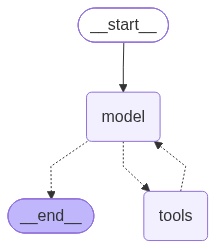

In [11]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [12]:
from langchain.tools import tool


@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    天气查询工具
    
    Args:
        city: 城市名称
    """
    return f"{city}的天气为晴朗，25°C。"

agent = create_agent(model=model, tools=[get_weather])

response = agent.invoke(
    {
        "messages": [
            {"role": "system", "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。"},
            {"role": "user", "content": "100加上50等于多少？"}
        ]
    }
)
rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='14f646ed-fb4a-4814-9e11-556c7a777961'
        ),
        HumanMessage(
            content='100加上50等于多少？',
            additional_kwargs={},
            response_metadata={},
            id='8b79f83a-6fec-460c-8fc6-b72c7883d6eb'
        ),
        AIMessage(
            content=[
                {
                    'type': 'text',
                    'text': '我不清楚这问题答案。',
                    'annotations': [],
                    'id': 'msg_1790564817967_jzkt7qffiy',
                    'phase': 'final_answer'
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'gen_01M3JZNNTHBSDVZA95NZW7969Q',
                'created_at': 1790564817.0,
                'metadata': {},
                'model': 'gpt-6-luna',
                'object': 'response',
                'service_tier': 'default',
                'status': 'completed',
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna'
            },
            id='gen_01M3JZNNTHBSDVZA95NZW7969Q',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 84,
                'output_tokens': 12,
                'total_tokens': 96,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ]
}

这个问题和天气无关，模型按系统消息直接回答，没有调用工具。所以返回的消息里只有一条 `AIMessage`：这次 agent 只调用了一次模型。

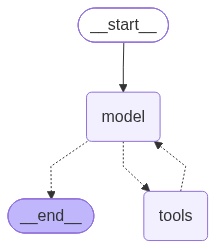

In [13]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 4.2.2 举例2：接入内置工具

In [15]:
import os
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from rich import print as rprint
from langchain.agents import create_agent
from langchain_tavily import TavilySearch

load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
OPENAI_API_BASE = os.environ["OPENAI_API_BASE"]  # 与本项目 .env 中的名称一致



model= ChatOpenAI(
    model="gpt-6-luna",  # 当前配置已验证可用；原 gpt-5.5 返回模型权限 403
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE,
)

web_search_tool = TavilySearch(
    tavily_api_key=os.environ["TAVILY_API_KEY"],
    max_results=5
)

#这是一个高度封装的网络搜索工具，可以直接调用：
web_search_tool.invoke("请问当前最流行的音乐有哪些")

{'query': '请问当前最流行的音乐有哪些',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://music.apple.com/cn/new/top-charts',
   'title': '\u200e热门音乐排行榜：歌曲、歌单、专辑、视频 - Apple Music',
   'content': 'Day and Night\n\n  Carly Rae Jepsen\n \n\n  6\n\n  you seem pretty sad for a girl so in love\n\n  Olivia Rodrigo [...] + 周杰伦\n \n\n  + 孙燕姿\n \n\n  5\n\n  + 晴天\n  + 周杰伦\n \n\n  6\n\n  + 明明就\n  + 周杰伦\n \n\n  7\n\n  + 花海\n  + 周杰伦\n \n\n  8\n\n  + 爱错\n  + 王力宏\n \n\n  9\n\n  + 开始懂了\n  + 孙燕姿\n \n\n  10\n\n  + 情歌\n  + 梁静茹\n \n\n  11\n\n  + 一路向北 (Bonus Track)\n  + 周杰伦\n \n\n  12\n\n  + 爱在西元前\n  + 周杰伦\n \n\n  13\n\n  + 等你下课 (with 杨瑞代)\n  + 周杰伦\n\n## 城市排行榜\n\n Top 25：上海\n\n  Top 25：上海\n\n  Top 25：上海\n\n  Apple Music\n Top 25：北京\n\n  Top 25：北京\n\n  Top 25：北京\n\n  Apple Music\n Top 25：成都\n\n  Top 25：成都\n\n  Top 25：成都\n\n  Apple Music\n Top 25：广州\n\n  Top 25：广州\n\n  Top 25：广州\n\n  Apple Music\n Top 25：武汉 [...] petal\n\n  petal\n\n  1\n\n  petal\n 太阳之子\n\n  太阳之子\n\n  2\n\n  太阳之子

In [16]:
import os
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from rich import print as rprint
from langchain.agents import create_agent
from langchain_tavily import TavilySearch

load_dotenv(override=True, verbose=True,dotenv_path="/Users/skk/Developer/lang-chain-learn/conf/.env")

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
OPENAI_API_BASE = os.environ["OPENAI_API_BASE"]  # 与本项目 .env 中的名称一致



model= ChatOpenAI(
    model="gpt-6-luna",  # 当前配置已验证可用；原 gpt-5.5 返回模型权限 403
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_API_BASE,
)

web_search_tool = TavilySearch(
    tavily_api_key=os.environ["TAVILY_API_KEY"],
    max_results=5
)

agent = create_agent(model=model, tools=[web_search_tool])

# 4.运行Agent获得结果
result = agent.invoke(
    {"messages": [{"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}]}
)
rprint(result)

{
    'messages': [
        HumanMessage(
            content='请帮我查询2024年诺贝尔物理学奖得主是谁？',
            additional_kwargs={},
            response_metadata={},
            id='23806ca5-b209-4f93-93d7-633717b74097'
        ),
        AIMessage(
            content=[
                {
                    'arguments': 
'{"end_date":null,"exclude_domains":[],"include_domains":["nobelprize.org"],"include_images":false,"query":"2024 
Nobel Prize in Physics laureates Nobel Prize 
official","search_depth":"basic","start_date":null,"time_range":null,"topic":"general"}',
                    'call_id': 'call_ai60wIbe6nf0NoUBL4l1LED9',
                    'name': 'tavily_search',
                    'type': 'function_call',
                    'id': 'fc_0e07d3fe666975b4016ab9df81136487d2bbbba223cd4dc0f4',
                    'status': 'completed',
                    'internal_chat_message_metadata_passthrough': {
                        'create_time': 1790566272.53252,
                        'turn_id': '01a0e611-0cab-7914-aa9a-f59c43f6eac7'
                    },
                    'metadata': {'turn_id': '01a0e611-0cab-7914-aa9a-f59c43f6eac7'}
                }
            ],
            additional_kwargs={},
            response_metadata={
                'id': 'resp_0e07d3fe666975b4016ab9df80634487d2930a8a140d82e798',
                'created_at': 1790566272.0,
                'metadata': {},
                'model': 'gpt-6-luna',
                'object': 'response',
                'service_tier': 'default',
                'status': 'completed',
                'model_provider': 'openai',
                'model_name': 'gpt-6-luna'
            },
            id='resp_0e07d3fe666975b4016ab9df80634487d2930a8a140d82e798',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {
                        'end_date': None,
                        'exclude_domains': [],
                        'include_domains': ['nobelprize.org'],
                        'include_images': False,
                        'query': '2024 Nobel Prize in Physics laureates Nobel Prize official',
                        'search_depth': 'basic',
                        'start_date': None,
                        'time_range': None,
                        'topic': 'general'
                    },
                    'id': 'call_ai60wIbe6nf0NoUBL4l1LED9',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 5569,
                'output_tokens': 73,
                'total_tokens': 5642,
                'input_token_details': {'cache_creation': 0, 'cache_read': 0},
                'output_token_details': {'reasoning': 0}
            }
        ),
        ToolMessage(
            content='{"query": "2024 Nobel Prize in Physics laureates Nobel Prize official", "follow_up_questions":
null, "answer": null, "images": [], "results": [{"url": 
"https://www.nobelprize.org/prizes/physics/2024/prize-announcement?_bhlid=177fecb0287afa4f05cf096849d363419f138f25"
, "title": "The Nobel Prize in Physics 2024 - Prize announcement - NobelPrize.org", "content": "Skip to content 
\\n\\n# Nobel Prize\\n\\n# Prize announcement\\n\\n \\n\\nAnnouncement of the 2024 Nobel Prize in Physics by 
Professor Hans Ellegren, Secretary General of the Royal Swedish Academy of Sciences, on 8 October 2024.\\n\\n## 
Interview about the awarded work\\n\\n### “They have both been true pioneers: finding new ways to tackle 
problems”\\n\\nImmediately after the announcement, Professor Anders Irbäck, Member of the Nobel Committee for 
Physics, was interviewed by journalist Lisa Kirsebom. [...] Go to the top of the page\\n\\n### Explore prizes and 
laureates\\n\\nLook for popular awards and laureates in different fields, and discover the history of the Nobel 
Prize.", "score": 0.86136365, "raw_content": null, "id": "06c4a5-00"}, {"url": 
"

## 4.3 agent.invoke 与模型 invoke 的区别

模型（如 `ChatOpenAI`）和 agent 都是 Runnable，都用 `invoke` 调用，但做的事情完全不同：

- **模型的 invoke**：把消息发给大模型，**调用一次**，拿回一条 `AIMessage`
- **agent 的 invoke**：从用户的问题开始，**运行整个循环**：调用模型 → 执行工具 → 再调用模型……直到得出最终答案，返回运行结束时的**状态**

两者的关系是：agent 内部的 `model` 节点，调用的正是模型的 invoke。源码（`langchain/agents/factory.py`）里就是这几行：

```python
messages = request.messages
if request.system_message:
    messages = [request.system_message, *messages]   # system_prompt 在这里临时加到最前面
output = model_.invoke(messages)                      # 调用（绑定了工具的）模型
```

也就是说，**一次 agent.invoke 里面，包着一次或多次模型的 invoke**。

### 4.3.1 输入和输出不同

模型的 invoke 可以直接传字符串，返回一条 `AIMessage`（会请求一次模型）：

In [19]:
ai_msg = model.invoke("你好")

print("返回值类型:", type(ai_msg).__name__)
print("回复内容:  ", ai_msg.text)

返回值类型: AIMessage
回复内容:   你好。你想让我帮你处理什么？


agent 的 invoke 则必须传一个字典，第 3 节已经看到它返回的也是字典。可以直接查看 agent 的输入、输出字段，再试试直接传字符串（都不请求模型）：

In [20]:
simple_agent = create_agent(model=model)

print("agent 的输入字段:", list(simple_agent.get_input_jsonschema()["properties"]))
print("agent 的输出字段:", list(simple_agent.get_output_jsonschema()["properties"]))

# 直接传字符串：在调用模型之前就报错
try:
    simple_agent.invoke("你好")
except Exception as e:
    print(type(e).__name__, "->", e)

agent 的输入字段: ['messages']
agent 的输出字段: ['messages', 'structured_response']
InvalidUpdateError -> Expected dict, got 你好
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE


输出字段里的 `structured_response` 只在设置了 `response_format` 时才有值（01 笔记 2.5.4）。

### 4.3.2 有工具时：模型只"请求"调用，agent 负责执行

同样绑定 4.2.1 的 `get_weather`，直接调用模型（会请求一次模型）：

In [21]:
model_with_tools = model.bind_tools([get_weather])
ai_msg = model_with_tools.invoke("请告诉我北京的天气。")

print("tool_calls:", ai_msg.tool_calls)
print("回复文本:  ", repr(ai_msg.text))

tool_calls: [{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_35fqSUClgBm7heo8N0aHPUoX', 'type': 'tool_call'}]
回复文本:   ''


模型只返回了"我要调用 `get_weather`，参数是北京"，工具没有执行，也没有最终答案。要拿到答案，得自己执行工具、把结果交回模型，再调用一次模型（第五章 `01-Tools_usage.ipynb` 1.4 节的做法）。

而 4.2.1 里 `agent.invoke` 返回的 5 条消息，说明 agent 把这些都做完了：

| 消息 | 由谁产生 | 相当于手动做的哪一步 |
|---|---|---|
| `SystemMessage`、`HumanMessage` | 输入 | 准备消息列表 |
| `AIMessage`（带 `tool_calls`） | `model` 节点 | 第 1 次调用模型的 invoke |
| `ToolMessage` | `tools` 节点 | 自己执行 `get_weather` |
| `AIMessage`（最终回答） | `model` 节点 | 第 2 次调用模型的 invoke |

### 4.3.3 取最终答案：`.content` 还是 `.text`？

对比第 3 节和 4.2.1 的输出会发现：没有工具时，`AIMessage.content` 是字符串；有工具时，`content` 变成了一个**列表**，文字藏在 `{"type": "text", "text": ...}` 里。

这是因为 `ChatOpenAI` 对 `gpt-6` 系列模型有一条规则：请求里带了工具，就改用 OpenAI 的 Responses API，而这个接口返回的 `content` 是内容块列表（第五章 `02-tool_define.ipynb` 也遇到过）。

所以取最终答案时，用 `.text` 最稳妥：不管 `content` 是字符串还是列表，它都返回纯文本。下面用和 4.2.1 输出相同结构的消息演示（不请求模型）：

In [22]:
from langchain_core.messages import AIMessage

final_msg = AIMessage(content=[
    {"type": "text", "text": "北京天气晴朗，气温 25°C。", "annotations": [], "id": "msg_demo", "phase": "final_answer"}
])

print(".content ->", final_msg.content)
print(".text    ->", final_msg.text)

.content -> [{'type': 'text', 'text': '北京天气晴朗，气温 25°C。', 'annotations': [], 'id': 'msg_demo', 'phase': 'final_answer'}]
.text    -> 北京天气晴朗，气温 25°C。


### 4.3.4 对比总结

| | 模型的 invoke | agent 的 invoke |
|---|---|---|
| 调用对象 | `ChatOpenAI` 等聊天模型 | `create_agent` 返回的 `CompiledStateGraph` |
| 输入 | 字符串、消息列表或 PromptValue | 字典 `{"messages": [...]}`，直接传字符串会报错 |
| 输出 | 一条 `AIMessage` | 字典 `{"messages": [完整的消息列表]}`；设置了 `response_format` 时还有 `structured_response` |
| 调用大模型的次数 | 1 次 | 1 次或多次，取决于要不要调用工具 |
| 工具 | `bind_tools` 后只返回 `tool_calls`，不会执行 | 自动执行工具，把结果交回模型，直到得出答案 |
| 对话历史 | 自己维护消息列表 | 返回完整的消息列表；配合 `checkpointer` 自动保存（01 笔记 2.5.5） |
| 取最终答案 | `ai_msg.text` | `result["messages"][-1].text` |
| `config` 里常用的设置 | `callbacks`、`tags` 等通用设置 | 通用设置，加上 `configurable.thread_id`（记忆）和 `recursion_limit`（最多执行多少步，`create_agent` 默认设为 9999） |

## 4.4 总结

1. 调用 agent：`agent.invoke({"messages": [...]})`。消息可以写成字符串、元组、字典或消息对象，外层的键名必须是 `messages`。
2. 返回值是运行结束时的状态（字典），`messages` 记录了整个过程。最终答案用 `result["messages"][-1].text` 取，不要依赖 `.content` 一定是字符串。
3. system 消息可以放在 messages 里，但它会被保存进状态；固定的角色设定更推荐用 `create_agent(system_prompt=...)`。
4. 通过 `tools` 参数接入工具，可以是 `@tool` 自定义的，也可以是内置的（如 `TavilySearch`）。模型需要时会调用工具，不需要时直接回答。
5. 模型的 invoke 调用一次、返回一条 `AIMessage`，工具只会被"请求"；agent 的 invoke 运行完整的循环，工具会被真正执行，一次 agent.invoke 里包着一次或多次模型的 invoke。